In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Future Verde River Flow Predictions

Loading our trained Verde River upstream and downstream flow models.

In [2]:
verde_downstream_model = joblib.load('../Output/verde_downstream_model.joblib')
verde_upstream_model = joblib.load('../Output/verde_upstream_model.joblib')

### SSP245 Climate Predictions

First we create a combined data file for making predictions.

In [3]:
# ==========================================
# 1. CREATING COMBINED DATA FILE
# ==========================================

# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv")

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_verde_upstream","log_flow_verde_downstream"]
history_columns_to_keep = list(df_future.columns) + extra_historical_targets

# Extract the top 20 rows with the designated features
df_history_top20 = df_history.tail(20)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_245 = pd.concat([df_history_top20, df_future], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_245["log_flow_verde_upstream_lag_1"] = df_combined_245["log_flow_verde_upstream"].shift(1)
df_combined_245["log_flow_verde_upstream_lag_11"] = df_combined_245["log_flow_verde_upstream"].shift(11)
df_combined_245["log_flow_verde_downstream_lag_5"] = df_combined_245["log_flow_verde_downstream"].shift(5)
df_combined_245["log_flow_verde_downstream_lag_6"] = df_combined_245["log_flow_verde_downstream"].shift(6)

Now we use our upstream flow model to predict future values of Verde upstream water flow with SSP245 climate predictions.

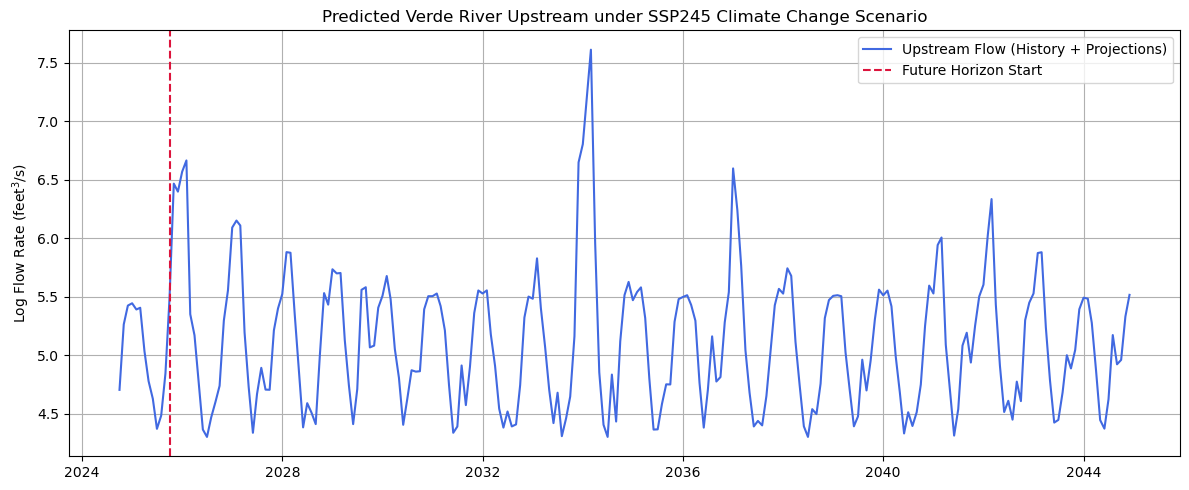

In [4]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_245.loc[i-1,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_245.loc[i-11,'log_flow_verde_upstream']
    df_combined_245.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_245[verde_upstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_upstream"], 
    label="Upstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_245["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Verde River Upstream under SSP245 Climate Change Scenario")
plt.ylabel("Log Flow Rate (feet$^3$/s)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../Output/verde_upstream_ssp245_projection.png", dpi=300, bbox_inches="tight")

plt.show()

Now we use our downstream model together with our Verde upstream flow predictions to predict future Verde downstream flow with SSP245 climate predictions.

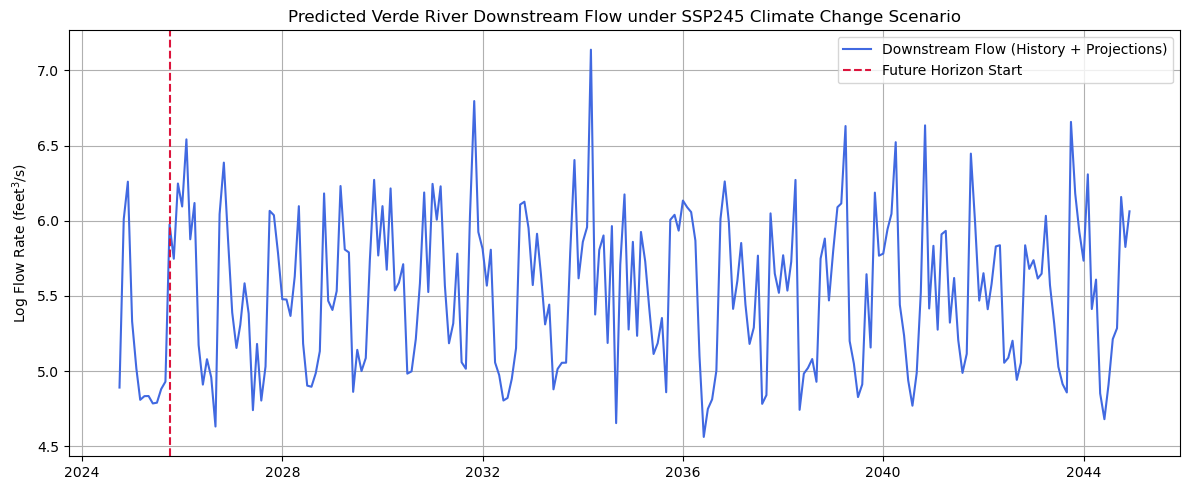

In [5]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

for i in range(12,len(df_combined_245.Time)):
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_245.loc[i-5,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_245.loc[i-6,'log_flow_verde_downstream']
    df_combined_245.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_245[verde_downstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_downstream"], 
    label="Downstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_245["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Verde River Downstream Flow under SSP245 Climate Change Scenario")
plt.ylabel("Log Flow Rate (feet$^3$/s)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../Output/verde_downstream_ssp245_projection.png", dpi=300, bbox_inches="tight")

plt.show()

### SSP585 Climate Predictions

First we create a combined data file for making predictions.

In [6]:
# ==========================================
# 1. CREATING COMBINED DATA FILE
# ==========================================

# Load historical and future data sets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future = pd.read_csv("../Data/FormattedData/FutureVals_SSP585Climate_and_AllOtherFeatures.csv")

# Define the columns we want to keep from the historical data
extra_historical_targets = ["log_flow_verde_upstream","log_flow_verde_downstream"]
history_columns_to_keep = list(df_future.columns) + extra_historical_targets

# Extract the top 20 rows with the designated features
df_history_top20 = df_history.tail(20)[history_columns_to_keep].copy()

# Combine historical and pojected future data vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined_585 = pd.concat([df_history_top20, df_future], axis=0).reset_index(drop=True)

# Create lag columns
df_combined_585["log_flow_verde_upstream_lag_1"] = df_combined_585["log_flow_verde_upstream"].shift(1)
df_combined_585["log_flow_verde_upstream_lag_11"] = df_combined_585["log_flow_verde_upstream"].shift(11)
df_combined_585["log_flow_verde_downstream_lag_5"] = df_combined_585["log_flow_verde_downstream"].shift(5)
df_combined_585["log_flow_verde_downstream_lag_6"] = df_combined_585["log_flow_verde_downstream"].shift(6)

Then we use our upstream flow model to predict future values of Verde upstream water flow with SSP585 climate predictions.

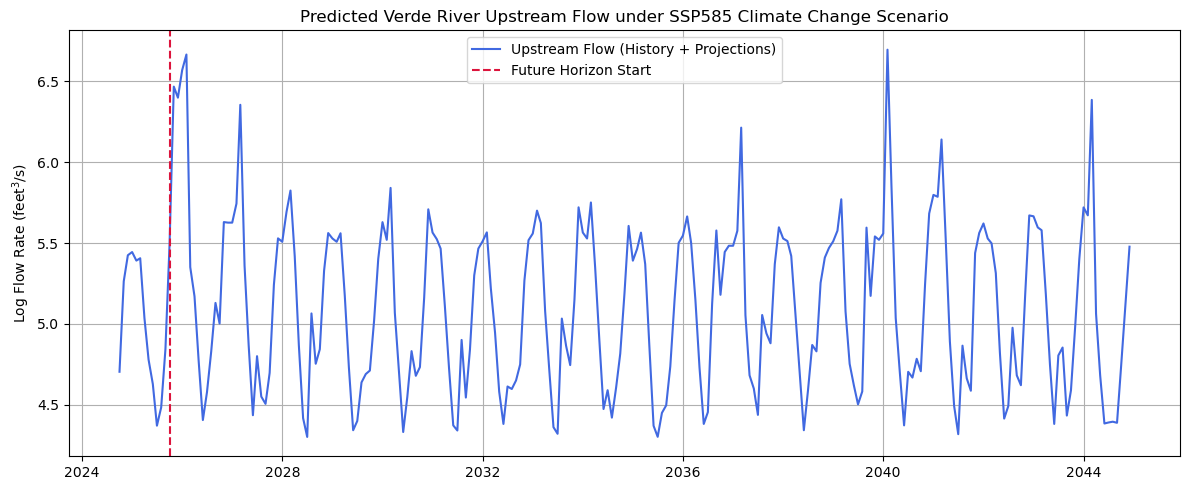

In [7]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined_585.loc[i-1,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined_585.loc[i-11,'log_flow_verde_upstream']
    df_combined_585.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined_585[verde_upstream_features].iloc[[i]])[0]
    

# ==========================================
# 3. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_upstream"], 
    label="Upstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Verde River Upstream Flow under SSP585 Climate Change Scenario")
plt.ylabel("Log Flow Rate (feet$^3$/s)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../Output/verde_upstream_ssp585_projection.png", dpi=300, bbox_inches="tight")

plt.show()

Now we use our downstream model together with our Verde upstream flow predictions to predict future Verde downstream flow with SSP585 climate predictions.

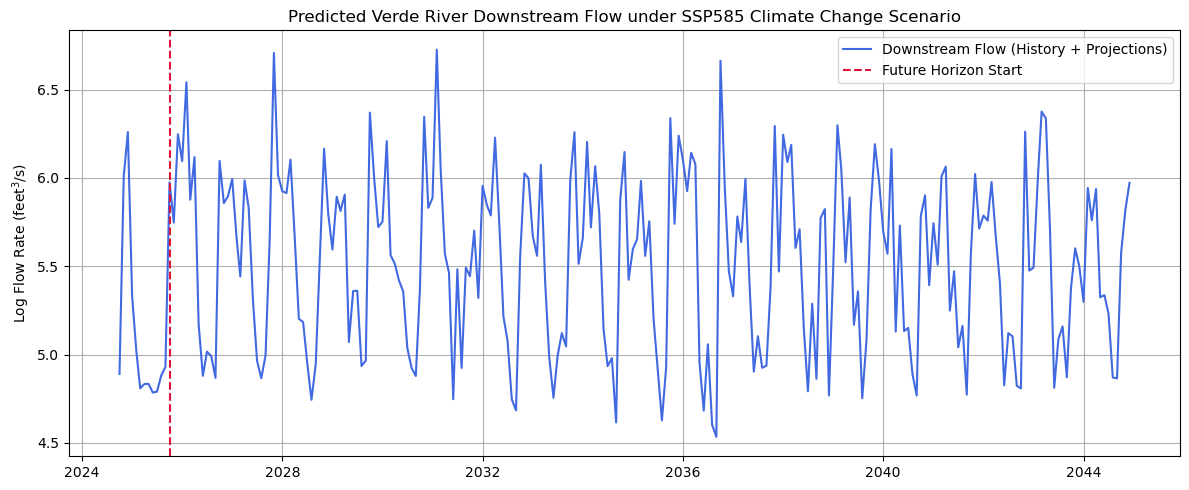

In [8]:
# ==========================================
# 1. CREATING FLOW PROJECTIONS
# ==========================================

verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

for i in range(12,len(df_combined_585.Time)):
    df_combined_585.loc[i,'log_flow_verde_downstream_lag_5'] = df_combined_585.loc[i-5,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream_lag_6'] = df_combined_585.loc[i-6,'log_flow_verde_downstream']
    df_combined_585.loc[i,'log_flow_verde_downstream'] = verde_downstream_model.predict(df_combined_585[verde_downstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_downstream"], 
    label="Downstream Flow (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Verde River Downstream Flow under SSP585 Climate Change Scenario")
plt.ylabel("Log Flow Rate (feet$^3$/s)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../Output/verde_downstream_ssp585_projection.png", dpi=300, bbox_inches="tight")

plt.show()

### Plotting both scenarios together

Plotting upstream and downstream flow on the same plot and comparing the two scenarios.

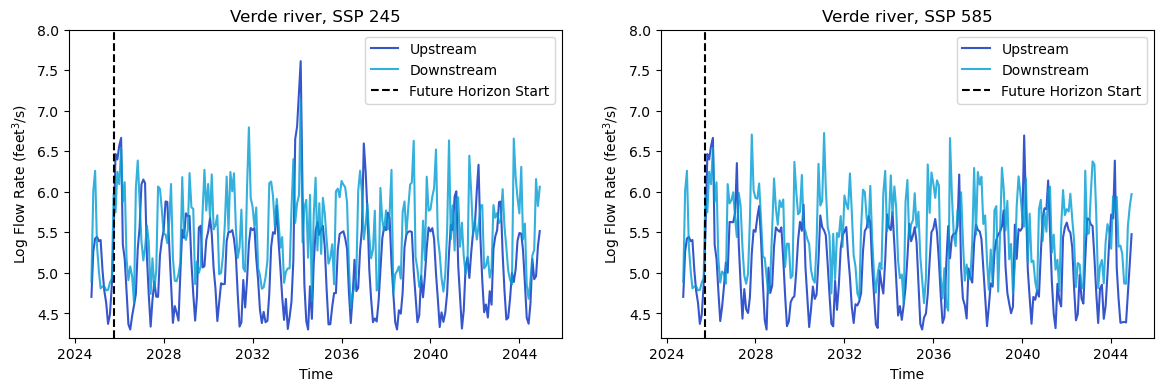

In [9]:
fig, ax = plt.subplots(1,2,figsize = (14,4))

ax[0].plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_upstream"], 
    label="Upstream", 
    color="#042CBF", alpha=0.8)
ax[0].plot(
    pd.to_datetime(df_combined_245["Time"]), 
    df_combined_245["log_flow_verde_downstream"], 
    label="Downstream", 
    color="#009cd4", alpha=0.8)
ax[0].axvline(pd.to_datetime(df_combined_245["Time"].iloc[12]), 
              color="black", linestyle="--", label="Future Horizon Start")
ax[0].legend()
ax[0].set_title("Verde river, SSP 245")
ax[0].set_ylim(4.2,8)
ax[0].set_ylabel("Log Flow Rate (feet$^3$/s)")
ax[0].set_xlabel("Time")

ax[1].plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_upstream"], 
    label="Upstream", 
    color="#042CBF", 
    alpha=0.8)
ax[1].plot(
    pd.to_datetime(df_combined_585["Time"]), 
    df_combined_585["log_flow_verde_downstream"], 
    label="Downstream", 
    color="#009cd4",
      alpha=0.8)
ax[1].axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="black", linestyle="--", label="Future Horizon Start")
ax[1].legend()
ax[1].set_title("Verde river, SSP 585")
ax[1].set_ylim(4.2,8)
ax[1].set_ylabel("Log Flow Rate (feet$^3$/s)")
ax[1].set_xlabel("Time")

#exporting to png
plt.savefig(
    "../Output/PredictedFlowRates_Verde.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Now we plot the difference between the log upstream flow and the log downstream flow.

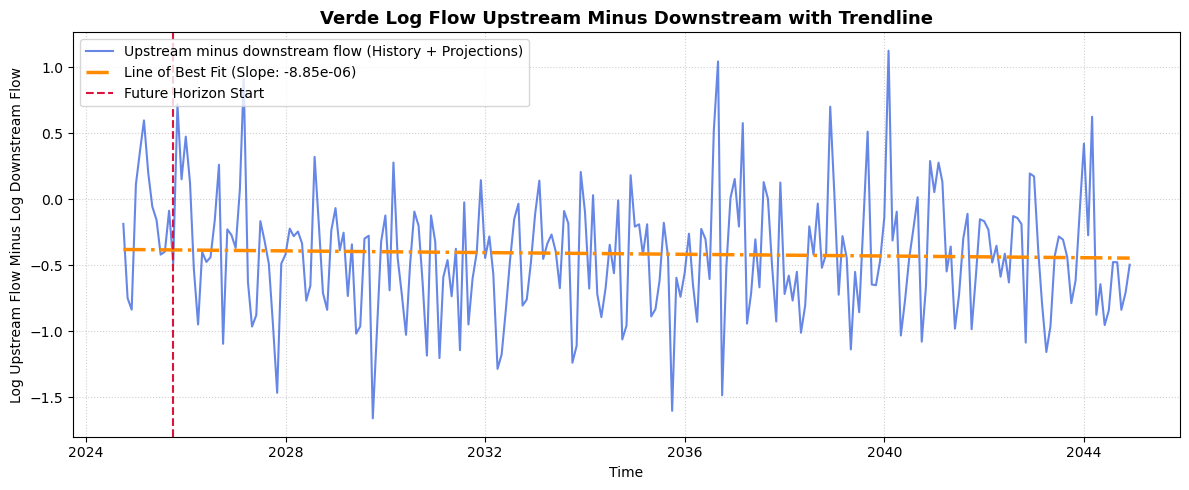

In [10]:
# 1. Calculate the difference metric
df_combined_585["difference_log_flow"] = df_combined_585["log_flow_verde_upstream"] - df_combined_585["log_flow_verde_downstream"]
df_combined_245["difference_log_flow"] = df_combined_245["log_flow_verde_upstream"] - df_combined_245["log_flow_verde_downstream"]

# 2. Convert Dates to numerical ordinals for the best-fit math
dates_converted = pd.to_datetime(df_combined_585["Time"])
x_numerical = dates_converted.map(pd.Timestamp.toordinal)
y_values = df_combined_585["difference_log_flow"]

# 3. Calculate Linear Regression Line (Degree 1 polynomial)
# slope (m) and intercept (b) for y = mx + b
slope, intercept = np.polyfit(x_numerical, y_values, 1)
best_fit_line = slope * x_numerical + intercept

# ==========================================
# 4. PLOTTING THE OUTPUT WITH BEST FIT LINE
# ==========================================
plt.figure(figsize=(12, 5))

# Plot your original time series line
plt.plot(
    dates_converted, 
    y_values, 
    label="Upstream minus downstream flow (History + Projections)", 
    color="royalblue",
    alpha=0.8
)

# Plot the best fit line
plt.plot(
    dates_converted, 
    best_fit_line, 
    label=f"Line of Best Fit (Slope: {slope:.2e})", 
    color="darkorange", 
    linestyle="-.", 
    linewidth=2.5
)

# Safe vertical line marker using .values[12]
if len(df_combined_585) > 12:
    cutoff_date = pd.to_datetime(df_combined_585["Time"].values[12])
    plt.axvline(cutoff_date, color="crimson", linestyle="--", label="Future Horizon Start")

# Styling
plt.title("Verde Log Flow Upstream Minus Downstream with Trendline", fontsize=13, fontweight='bold')
plt.ylabel("Log Upstream Flow Minus Log Downstream Flow")
plt.xlabel("Time")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

Now we calculate the cumulative change over time (cumulative sum of upstream minus downstream, converted from cubic-feet/s to acre-feet/month), which gives us an idea of the change in water storage levels in the Verde river reservoirs.

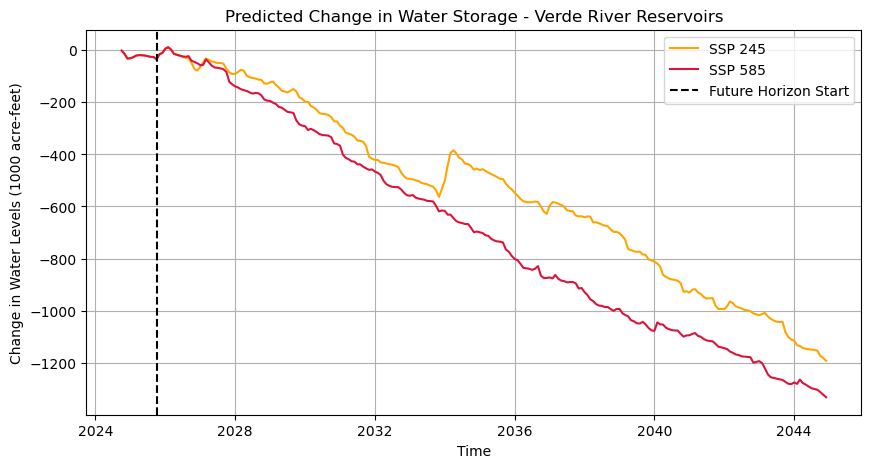

In [11]:
#Back tranforming log flow to original scale and then taking the difference
df_combined_585["difference_flow"] = np.expm1(df_combined_585["log_flow_verde_upstream"]) - np.expm1(df_combined_585["log_flow_verde_downstream"])
df_combined_245["difference_flow"] = np.expm1(df_combined_245["log_flow_verde_upstream"])- np.expm1(df_combined_245["log_flow_verde_downstream"])
#Calculating cumulative difference
df_combined_585["CumDiff_flow"] = df_combined_585["difference_flow"].cumsum()
df_combined_245["CumDiff_flow"] = df_combined_245["difference_flow"].cumsum()

#plotting
plt.figure(figsize=(10, 5))

plt.plot(
    pd.to_datetime(df_combined_245["Time"]), 
    (df_combined_245["CumDiff_flow"]*60.3)/1000, 
    label="SSP 245", 
    color="orange")
plt.plot(
    pd.to_datetime(df_combined_585["Time"]), 
    (df_combined_585["CumDiff_flow"]*60.3)/1000, 
    label="SSP 585", 
    color="crimson")
plt.axvline(pd.to_datetime(df_combined_585["Time"].iloc[12]), color="black", linestyle="--", label="Future Horizon Start")
plt.title("Predicted Change in Water Storage - Verde River Reservoirs")
plt.ylabel("Change in Water Levels (1000 acre-feet)")
plt.xlabel("Time")
plt.grid(True)
plt.legend()

plt.savefig(
    "../Output/PredictedCumulativeChange_Verde.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Saving the predicted values.

In [12]:
df_combined_245[['Time','log_flow_verde_upstream', 'log_flow_verde_downstream',
                 'difference_log_flow', 'difference_flow',
                    'CumDiff_flow']].to_csv("../Output/PredictedFlowValues_Verde_SSP245.csv")
df_combined_585[['Time','log_flow_verde_upstream', 'log_flow_verde_downstream',
                 'difference_log_flow', 'difference_flow',
                    'CumDiff_flow']].to_csv("../Output/PredictedFlowValues_Verde_SSP585.csv")